In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os
base_path = "/content/drive/MyDrive"
os.listdir(base_path)


['Copy of MC1_2018.zip',
 'Copy of MC1_2018.zip (Unzipped Files)',
 '2018 Mini-Challenge 1.zip (Unzipped Files)',
 'Colab Notebooks',
 'Varun_Reddy_Samreddy.docx',
 'VarunReddy Samreddy.pdf',
 'Essay (1).docx',
 'Essay.docx',
 'Dataset']

In [5]:
dataset_path = "/content/drive/MyDrive/Dataset"
print(os.listdir(dataset_path))


['Proliferate DR', 'Moderate DR', 'Healthy', 'Severe DR', 'Mild DR']


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
classes_list = ["Healthy", "Mild DR", "Moderate DR", "Severe DR"]

datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    classes=classes_list
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    classes=classes_list
)

train_generator.class_indices


Found 1968 images belonging to 4 classes.
Found 492 images belonging to 4 classes.


{'Healthy': 0, 'Mild DR': 1, 'Moderate DR': 2, 'Severe DR': 3}

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = train_generator.num_classes
print("Number of classes:", num_classes)

model = models.Sequential([
    layers.Conv2D(8, (3, 3), activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(4, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(8, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()


Number of classes: 4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 4)      │           292 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        28,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,360 (114.69 KB)

 Trainable params: 29,360 (114.69 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS = 20

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 604s 10s/step - accuracy: 0.3491 - loss: 1.2629 - val_accuracy: 0.4065 - val_loss: 1.1472
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 30s 474ms/step - accuracy: 0.4205 - loss: 1.1285 - val_accuracy: 0.5427 - val_loss: 0.9534
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 31s 494ms/step - accuracy: 0.6302 - loss: 0.9132 - val_accuracy: 0.7093 - val_loss: 0.8829
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 30s 478ms/step - accuracy: 0.6865 - loss: 0.8780 - val_accuracy: 0.7093 - val_loss: 0.8487
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 29s 467ms/step - accuracy: 0.6843 - loss: 0.8849 - val_accuracy: 0.7012 - val_loss: 0.8204
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 30s 475ms/step - accuracy: 0.7085 - loss: 0.8085 - val_accuracy: 0.7175 - val_loss: 0.7957
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 30s 479ms/step - accuracy: 0.7118 - loss: 0.7978 - val_accuracy: 0.7134 - val_loss: 0.7885
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 30s 484ms/step - accuracy: 0.7167 - loss: 0.7830 - val_accur

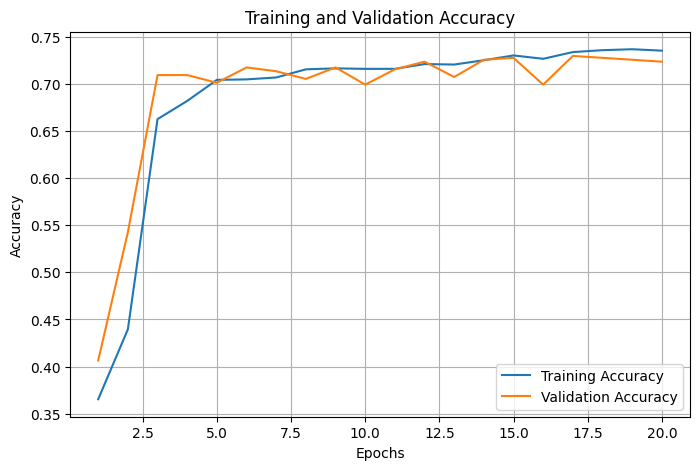

In [9]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = train_generator.num_classes
print("Number of classes:", num_classes)

def build_cnn(hidden_units):
    model = models.Sequential([
        layers.Conv2D(8, (3, 3), activation='relu',
                      input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(4, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(hidden_units, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


Number of classes: 4


In [11]:
EPOCHS = 20
model_8 = build_cnn(hidden_units=8)
history_8 = model_8.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    verbose=1
)
model_4 = build_cnn(hidden_units=4)
history_4 = model_4.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    verbose=1
)
model_16 = build_cnn(hidden_units=16)
history_16 = model_16.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    verbose=1
)


Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 31s 472ms/step - accuracy: 0.3254 - loss: 1.2932 - val_accuracy: 0.3659 - val_loss: 1.2371
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 29s 472ms/step - accuracy: 0.3384 - loss: 1.2109 - val_accuracy: 0.4065 - val_loss: 1.1422
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 29s 475ms/step - accuracy: 0.4239 - loss: 1.0777 - val_accuracy: 0.7012 - val_loss: 0.8555
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 29s 473ms/step - accuracy: 0.6721 - loss: 0.8229 - val_accuracy: 0.7337 - val_loss: 0.7742
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 30s 476ms/step - accuracy: 0.7123 - loss: 0.7613 - val_accuracy: 0.7398 - val_loss: 0.7249
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 31s 508ms/step - accuracy: 0.7228 - loss: 0.7251 - val_accuracy: 0.7195 - val_loss: 0.7428
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 30s 475ms/step - accuracy: 0.7305 - loss: 0.6939 - val_accuracy: 0.7317 - val_loss: 0.6995
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 29s 476ms/step - accuracy: 0.7351 - loss: 0.6610 - val_accu

In [12]:
import matplotlib.pyplot as plt

def plot_history(history, title_suffix=""):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(7, 5))
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Training and Validation Accuracy {title_suffix}')
    plt.legend()
    plt.grid(True)
    plt.show()


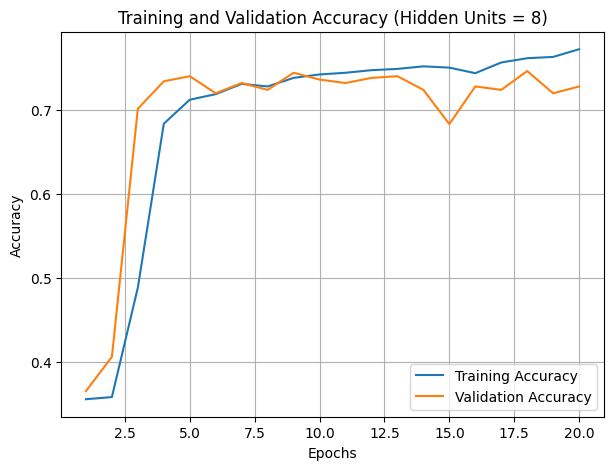

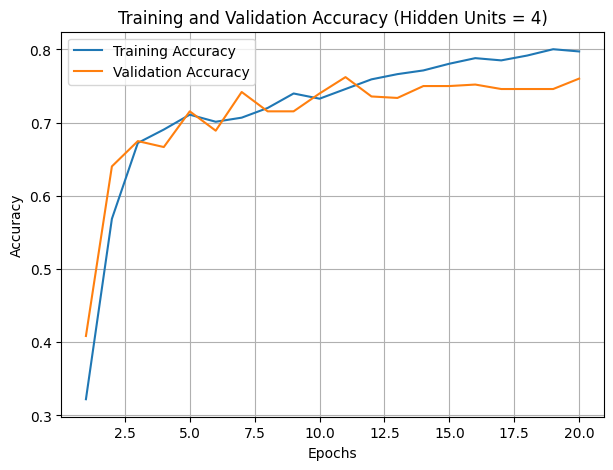

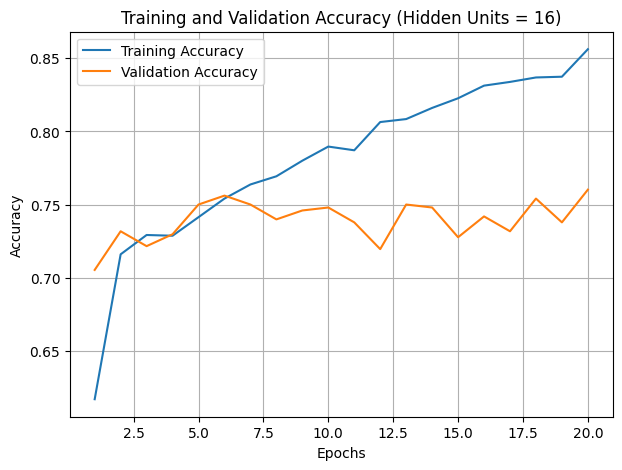

In [13]:
plot_history(history_8, title_suffix="(Hidden Units = 8)")
plot_history(history_4, title_suffix="(Hidden Units = 4)")
plot_history(history_16, title_suffix="(Hidden Units = 16)")


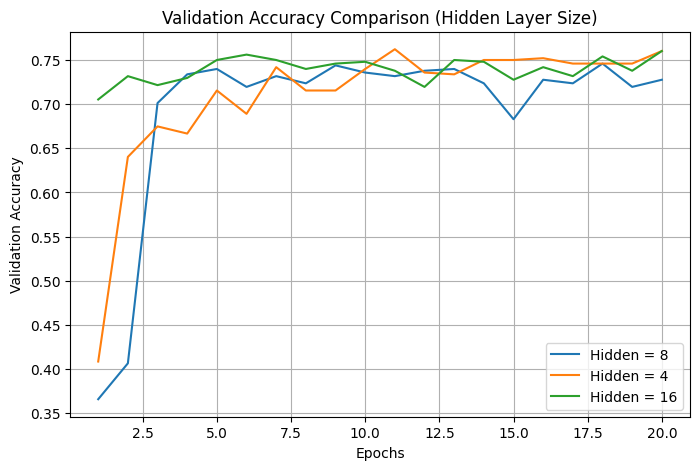

In [14]:
val_acc_8 = history_8.history['val_accuracy']
val_acc_4 = history_4.history['val_accuracy']
val_acc_16 = history_16.history['val_accuracy']
epochs_range = range(1, len(val_acc_8) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, val_acc_8, label='Hidden = 8')
plt.plot(epochs_range, val_acc_4, label='Hidden = 4')
plt.plot(epochs_range, val_acc_16, label='Hidden = 16')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison (Hidden Layer Size)')
plt.legend()
plt.grid(True)
plt.show()


Here we have used the Diabetic Retinopathy dataset and constructed the baseline CNN with 8 hidden units in the fully connected layer. I then trained two additional models with 4 and 16 hidden units, respectively, keeping all other hyperparameters fixed.

The model with 4 hidden units had lower capacity and generally showed lower training and validation accuracy, especially in later epochs, which suggests a tendency toward **underfitting**.

The model with 16 hidden units achieved higher training accuracy and slight variation in  validation accuracy compared to the baseline.
This indicates the model is fitting the training data too well but not generalizing as well to the validation set, so it shows signs of **overfitting**.

With the model with 8, training accuracy reached a reasonably high level, and validation accuracy followed it fairly closely. There might be a small gap between training and validation, but not as large as the 16-unit model. This model strikes a good balance between bias and variance, so I believe it is **just right** for this dataset.